In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ls

drive/  sample_data/


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter)
from dataclasses import dataclass

In [ ]:
#When people use your seed number, they can see exactly the results you did when u tested yours
SEED_VALUE = 42

#Fix seed to make training deterministic
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


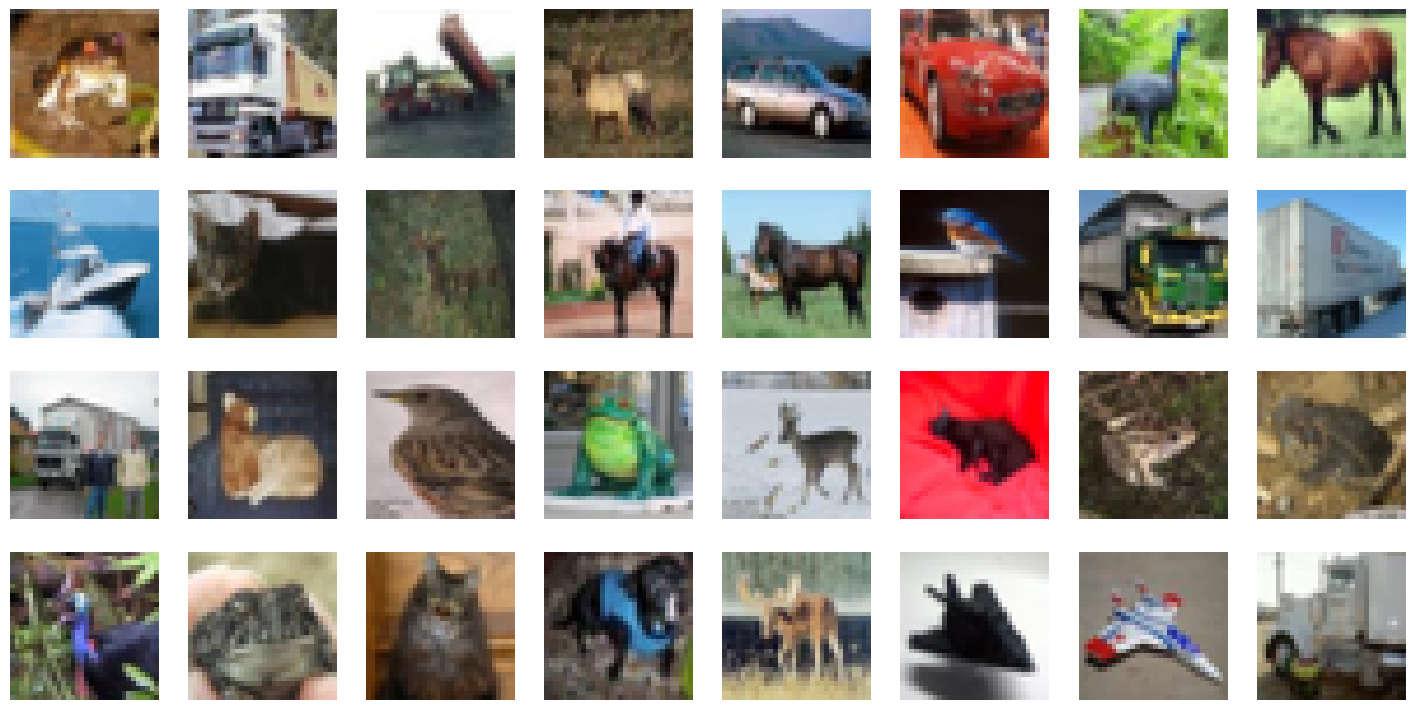

In [ ]:
plt.figure(figsize=(18,9))

num_rows = 4
num_cols = 8

#plot each of the images in the batch and the associated ground truth labels.
for i in range(num_rows*num_cols):
  ax = plt.subplot(num_rows, num_cols, i+1)
  plt.imshow(X_train[i,:,:])
  plt.axis("off")

In [ ]:
#Normalize images to the range[0, 1].

X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255\

#Change the tables from integer to categorical data
print('Original (integer) label for the first training sample ', y_train[0])

#Convert labels to one-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print('After conversion to categorical one-hot encoded labels: ', y_train[0])

Original (integer) label for the first training sample  [6]
After conversion to categorical one-hot encoded labels:  [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [ ]:
@dataclass(frozen = True)
class DatasetConfig:
  NUM_CLASSES: int = 10
  IMG_HEIGHT: int = 32
  IMG_WIDTH: int = 32
  NUM_CHANNELS: int = 3

@dataclass(frozen=True)
class TrainingConfig:
  EPOCHS: int = 31
  BATCH_SIZE: int = 256
  LEARNING_RATE: float = 0.001

In [ ]:
def cnn_model(input_shape=(32, 32, 3)):

  model = Sequential()

  #Conv block 1: 32 filters, Maxpool
  model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=input_shape))
  model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  #Conv block 2: 64 filters, Maxpool
  model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
  model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  #Conv block 3: 64 Filters, maxpoool
  model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
  model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  #Flatten the convolutional features
  model.add(Flatten())
  model.add(Dense(512, activation='relu'))
  model.add(Dense(10, activation='softmax'))

  return model


In [ ]:
#Create the model
model = cnn_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,354 (2.55 MB)

 Trainable params: 669,354 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'],
              )

In [ ]:
history = model.fit(X_train,
                    y_train,
                    batch_size=TrainingConfig.BATCH_SIZE,
                    epochs=TrainingConfig.EPOCHS,
                    verbose=1,
                    validation_split=.3,
                    )


Epoch 1/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.1526 - loss: 2.2438 - val_accuracy: 0.3489 - val_loss: 1.8493
Epoch 2/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.3402 - loss: 1.8033 - val_accuracy: 0.2744 - val_loss: 2.0464
Epoch 3/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.4210 - loss: 1.5912 - val_accuracy: 0.3953 - val_loss: 1.7521
Epoch 4/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.4898 - loss: 1.4125 - val_accuracy: 0.4963 - val_loss: 1.3896
Epoch 5/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.5470 - loss: 1.2541 - val_accuracy: 0.5567 - val_loss: 1.2331
Epoch 6/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.5989 - loss: 1.1170 - val_accuracy: 0.6011 - val_loss: 1.1018
Epoch 7/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.6418 - loss: 1.0024 - val_accuracy: 0.5977 - val_loss: 1.1416
Epoch 8/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.6809 - loss: 0.9009 - val_acc

In [ ]:
def plot_results(metrics, title=None, ylabel=None, ylim=None, metric_name=None, color=None):

  fig, ax = plt.subplots(figsize=(15, 4))

  if not (isinstance(metric_name, list) or isinstance(metric_name, tuple)):
    metrics = [metrics,]
    metric_name = [metric_name,]

  for idx, metric in enumerate(metrics):
    ax.plot(metric, color=color[idx])

  plt.xlabel("Epoch")
  plt.ylabel(ylabel)
  plt.title(title)
  plt.xlim([0, TrainingConfig.EPOCHS -1 ])
  plt.ylim(ylim)

  #Tailor x-axis tick marks

  ax.xaxis.set_major_locator(MultipleLocator(5))
  ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
  ax.xaxis.set_minor_locator(MultipleLocator(1))
  plt.grid(True)
  plt.legend(metric_name)
  plt.show()
  plt.close()

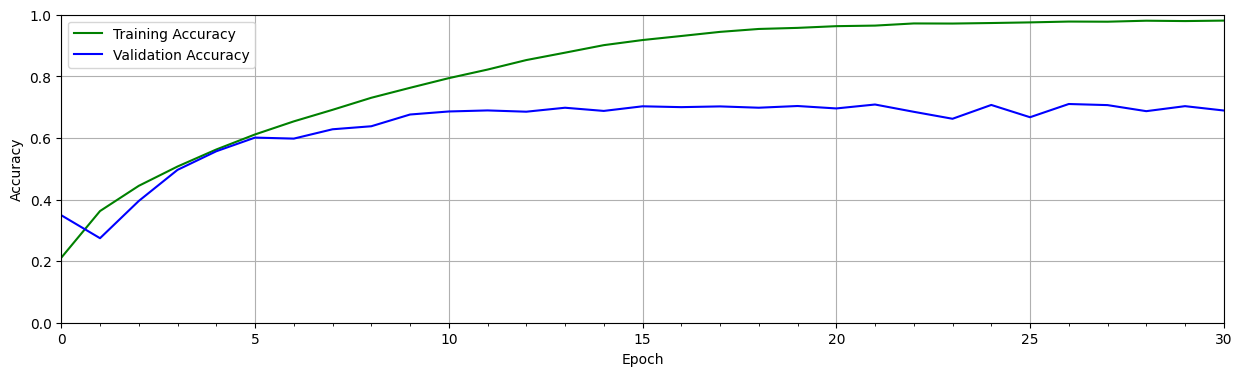

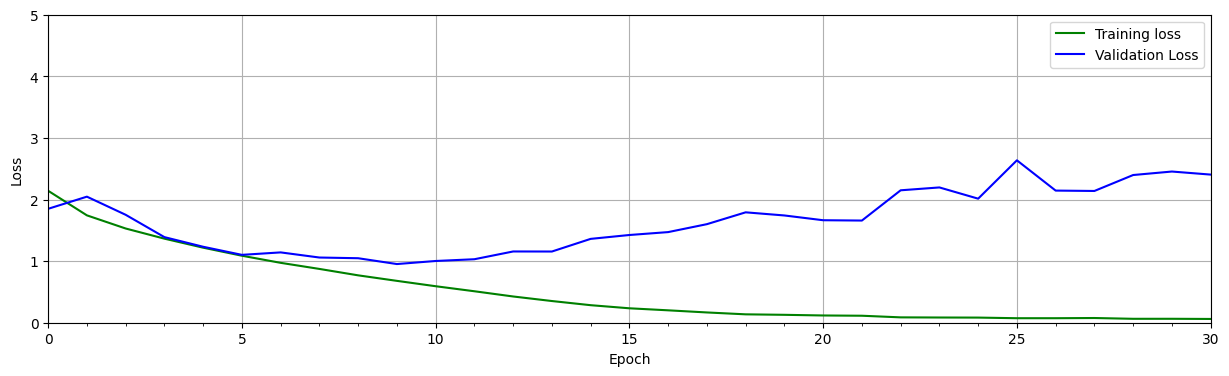

In [ ]:
#Retrieve Training results
train_loss = history.history["loss"]
train_acc = history.history["accuracy"]
valid_loss = history.history["val_loss"]
valid_acc = history.history["val_accuracy"]

plot_results([ train_acc, valid_acc],
             ylabel="Accuracy",
             ylim= [0.0, 1.0],
             metric_name=["Training Accuracy", "Validation Accuracy"],
             color=["g", "b"])

plot_results([ train_loss, valid_loss],
             ylabel="Loss",
             ylim = [0.0, 5.0],
             metric_name=["Training loss", "Validation Loss"],
             color=["g", "b"]);



In [ ]:
def cnn_model_dropout(input_shape=(32, 32, 3)):

  model = Sequential()

  #Conv block 1: 32 filters, Maxpool
  model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=input_shape))
  model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  #Conv block 2: 64 filters, Maxpool
  model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
  model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  #Conv block 3: 64 Filters, maxpoool
  model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
  model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  #Flatten the convolutional features
  model.add(Flatten())
  model.add(Dense(512, activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(10, activation='softmax'))

  return model


In [ ]:
#Create the model
model_dropout = cnn_model_dropout()
model_dropout.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,354 (2.55 MB)

 Trainable params: 669,354 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_dropout.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'],
              )

In [ ]:
history_dropout = model_dropout.fit(X_train,
                    y_train,
                    batch_size=TrainingConfig.BATCH_SIZE,
                    epochs=TrainingConfig.EPOCHS,
                    verbose=1,
                    validation_split=.3,
                    )

Epoch 1/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.1676 - loss: 2.2287 - val_accuracy: 0.2147 - val_loss: 2.2469
Epoch 2/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3016 - loss: 1.8918 - val_accuracy: 0.3929 - val_loss: 1.6531
Epoch 3/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.3861 - loss: 1.6599 - val_accuracy: 0.3895 - val_loss: 1.6716
Epoch 4/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4473 - loss: 1.5292 - val_accuracy: 0.5023 - val_loss: 1.3732
Epoch 5/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.4973 - loss: 1.4010 - val_accuracy: 0.4891 - val_loss: 1.4827
Epoch 6/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5381 - loss: 1.2916 - val_accuracy: 0.5586 - val_loss: 1.2359
Epoch 7/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5703 - loss: 1.2093 - val_accuracy: 0.5771 - val_loss: 1.1737
Epoch 8/31
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5967 - loss: 1.1353 - val_acc

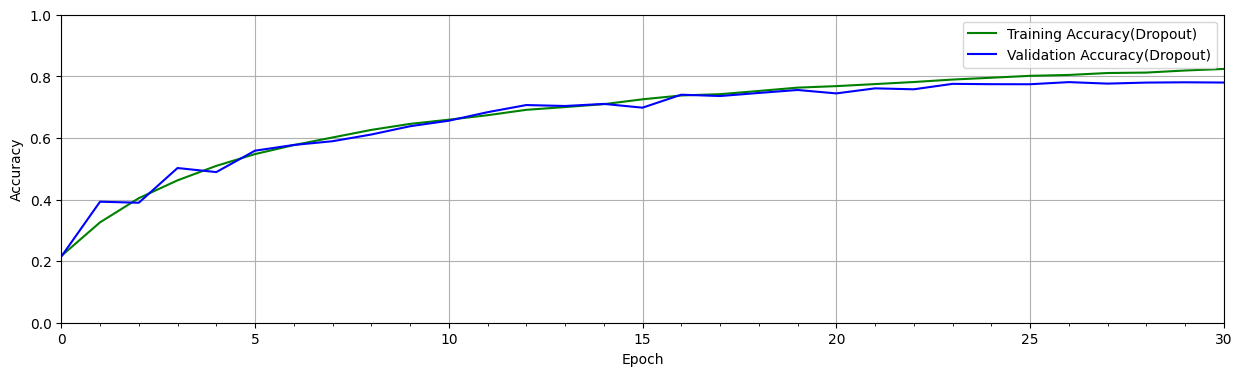

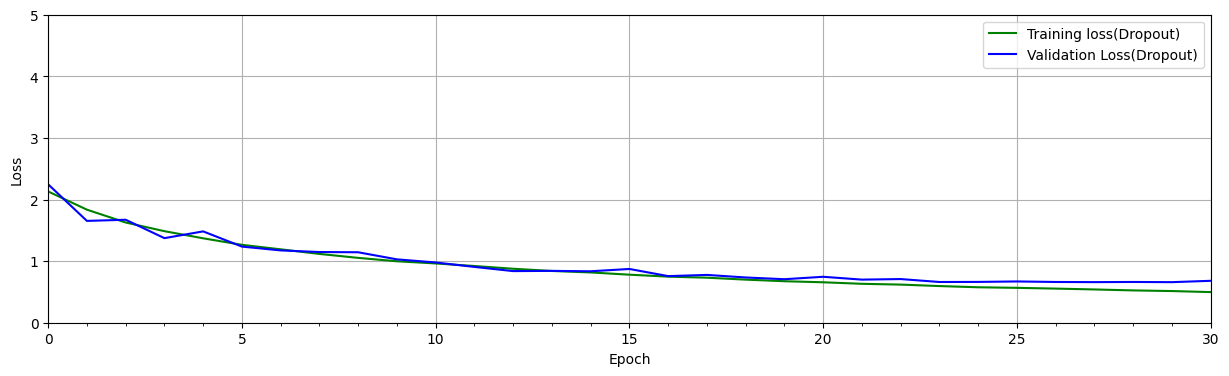

In [ ]:
#Retrieve Training results
train_loss_dropout = history_dropout.history["loss"]
train_acc_dropout = history_dropout.history["accuracy"]
valid_loss_dropout = history_dropout.history["val_loss"]
valid_acc_dropout = history_dropout.history["val_accuracy"]

plot_results([ train_acc_dropout, valid_acc_dropout],
             ylabel="Accuracy",
             ylim= [0.0, 1.0],
             metric_name=["Training Accuracy(Dropout)", "Validation Accuracy(Dropout)"],
             color=["g", "b"])

plot_results([ train_loss_dropout, valid_loss_dropout],
             ylabel="Loss",
             ylim = [0.0, 5.0],
             metric_name=["Training loss(Dropout)", "Validation Loss(Dropout)"],
             color=["g", "b"]);



In [ ]:
model_dropout.save('model_dropout.keras')

In [ ]:
from tensorflow.keras import models
reloaded_model_dropout = models.load_model('model_dropout.keras')

In [ ]:
test_loss, test_acc = reloaded_model_dropout.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc*100:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7693 - loss: 0.6971
Test accuracy: 77.220
